In [ ]:
# import secrets
# print(secrets.token_hex(32))

In [54]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from datetime import datetime

In [7]:
with sqlite3.connect("../data/spa.db") as conn:
    df_network_metrics = pd.read_sql_query("SELECT * from network_metrics", conn)
    df_process_metrics = pd.read_sql_query("SELECT * from process_metrics", conn)
    df_system_metrics = pd.read_sql_query("SELECT * from system_metrics", conn)

In [8]:
df_network_metrics.head()

,id,username,timestamp,upload_speed_mb,download_speed_mb,bytes_sent,bytes_received
0,1,Admin,2026-04-25 15:27:05,0.02,0.01,23625595,3195704
1,2,Admin,2026-04-25 15:27:21,0.04,0.05,23873945,4072682
2,3,Admin,2026-04-25 15:27:37,0.01,0.00,25552795,4112728
3,4,Admin,2026-04-25 15:27:53,0.00,0.00,25574260,4122968
4,5,Admin,2026-04-25 15:28:09,0.14,3.16,25787023,7590690


In [24]:
df_process_metrics.head(20)

,id,username,timestamp,process_name,cpu_percent,memory_percent
0,1,Admin,2026-04-25 15:27:05,System Idle Process,0.0,0.000048
1,2,Admin,2026-04-25 15:27:05,System,0.0,0.023064
2,3,Admin,2026-04-25 15:27:05,svchost.exe,0.0,0.009895
3,4,Admin,2026-04-25 15:27:05,,0.0,0.389850
4,5,Admin,2026-04-25 15:27:05,Registry,0.0,0.280645
5,6,Admin,2026-04-25 15:27:05,Code.exe,0.0,0.906361
6,7,Admin,2026-04-25 15:27:05,smss.exe,0.0,0.004502
7,8,Admin,2026-04-25 15:27:05,csrss.exe,0.0,0.019284
8,9,Admin,2026-04-25 15:27:05,conhost.exe,0.0,0.040302
9,10,Admin,2026-04-25 15:27:05,wininit.exe,0.0,0.023160


In [25]:
df_system_metrics.head()

,id,username,timestamp,overall_cpu_load,vm_total_memory,vm_available_memory,vm_used_memory,vm_percent_used,swap_memory_available_total,swap_memory_used,battery_percent
0,1,Admin,2026-04-25 15:27:05,14.350,17.01,4.21,12.81,75.3,12.88,1.29,99.0
1,2,Admin,2026-04-25 15:27:21,27.175,17.01,3.80,13.21,77.7,12.88,1.27,99.0
2,3,Admin,2026-04-25 15:27:37,14.350,17.01,3.56,13.45,79.1,12.88,1.27,99.0
3,4,Admin,2026-04-25 15:27:53,4.150,17.01,3.70,13.31,78.2,12.88,1.27,99.0
4,5,Admin,2026-04-25 15:28:09,16.475,17.01,3.53,13.49,79.3,12.88,1.27,99.0


## Graphs For Analysis

- CPU Load Trend Over Time
- Memory Usage Trend Over Time
- Battery Percentage Trend Over Time
- CPU for Processes
- Memory for Processes
- Network Speed and Usage Over Time

In [94]:
NAVY = "#1E2761"
ACCENT = "#4B9FE1"
TEAL = "#0D9488"
GREEN = "#22C55E"
RED = "#EF4444"

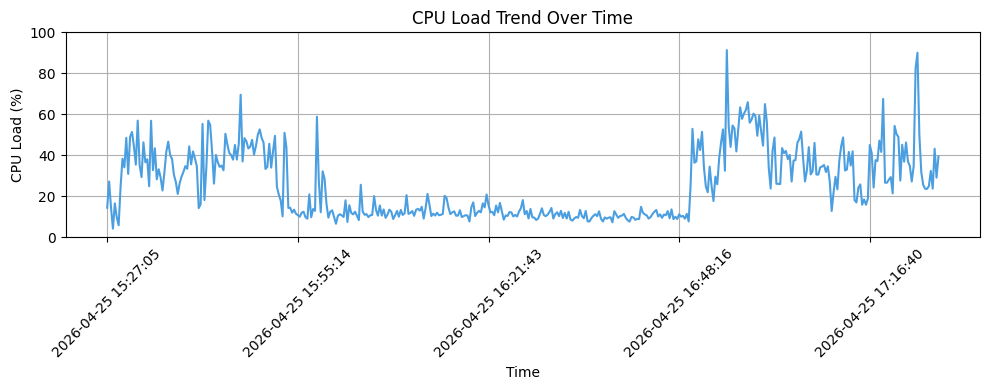

In [50]:
plt.figure(figsize=(10, 4))
plt.plot(df_system_metrics["timestamp"], df_system_metrics["overall_cpu_load"], color=ACCENT)
plt.title("CPU Load Trend Over Time")
plt.xlabel("Time")
plt.ylabel("CPU Load (%)")
plt.ylim(0,100)
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(5))
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show();

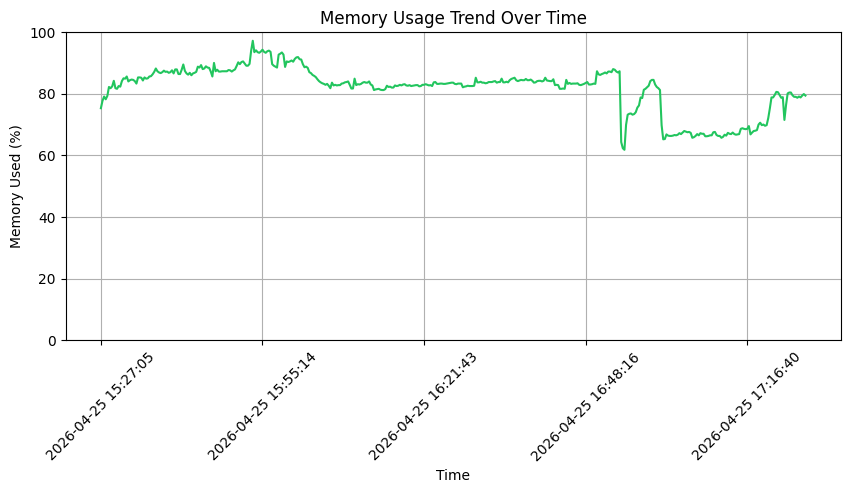

In [51]:
plt.figure(figsize=(10, 4))
plt.plot(df_system_metrics["timestamp"], df_system_metrics["vm_percent_used"], color=GREEN)
plt.title("Memory Usage Trend Over Time")
plt.xlabel("Time")
plt.ylabel("Memory Used (%)")
plt.ylim(0,100)
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(5))
plt.xticks(rotation=45)
plt.grid(True)

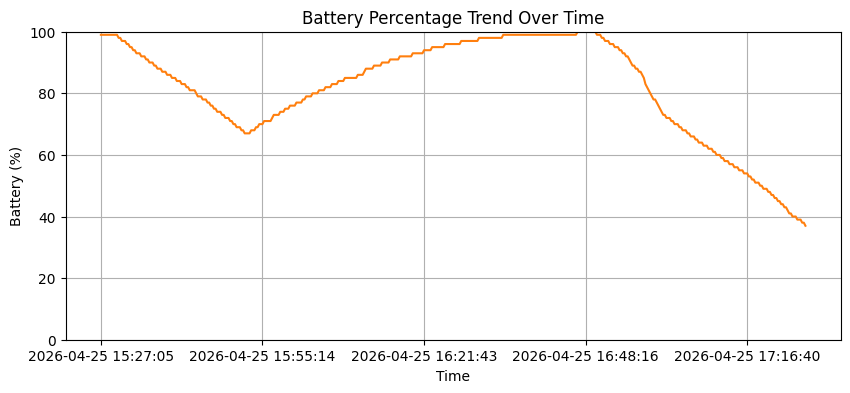

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(df_system_metrics["timestamp"], df_system_metrics["battery_percent"], color="#ff7f0e",)
plt.title("Battery Percentage Trend Over Time")
plt.xlabel("Time")
plt.ylabel("Battery (%)")
plt.ylim(0,100)
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(5))
plt.xticks(rotation=45)
plt.grid(True)

In [58]:
process_data = df_process_metrics[pd.to_datetime(df_process_metrics["timestamp"]).dt.day == 25]
process_clean = process_data[process_data['process_name'] != "System Idle Process"]
process_agg = process_clean.groupby(['process_name', 'timestamp']).agg({'cpu_percent': 'sum', 'memory_percent': 'sum'}).reset_index()
# Get top 10 CPU-consuming processes
top10_cpu_processes = process_agg.groupby('process_name')['cpu_percent'].sum().sort_values(ascending=False).head(10).index
agg_top10 = process_agg[process_agg['process_name'].isin(top10_cpu_processes)]
cpu_total = agg_top10.groupby('process_name')['cpu_percent'].sum()
memory_total = agg_top10.groupby('process_name')['memory_percent'].sum()
# Normalize to 100%
cpu_total_norm = cpu_total / cpu_total.sum() * 100
memory_total_norm = memory_total / memory_total.sum() * 100

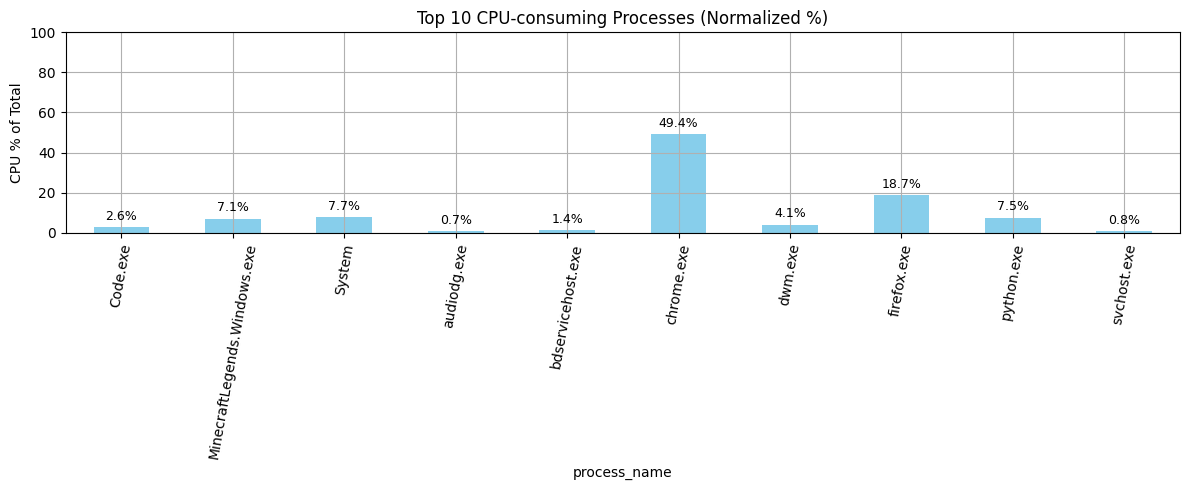

In [67]:
plt.figure(figsize=(12,5))
ax = cpu_total_norm.plot(kind='bar', color='skyblue')
plt.title('Top 10 CPU-consuming Processes (Normalized %)')
plt.ylabel('CPU % of Total')
plt.ylim(0,100)
plt.xticks(rotation=80)
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.1f}%', (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')
plt.tight_layout()
plt.grid(True)

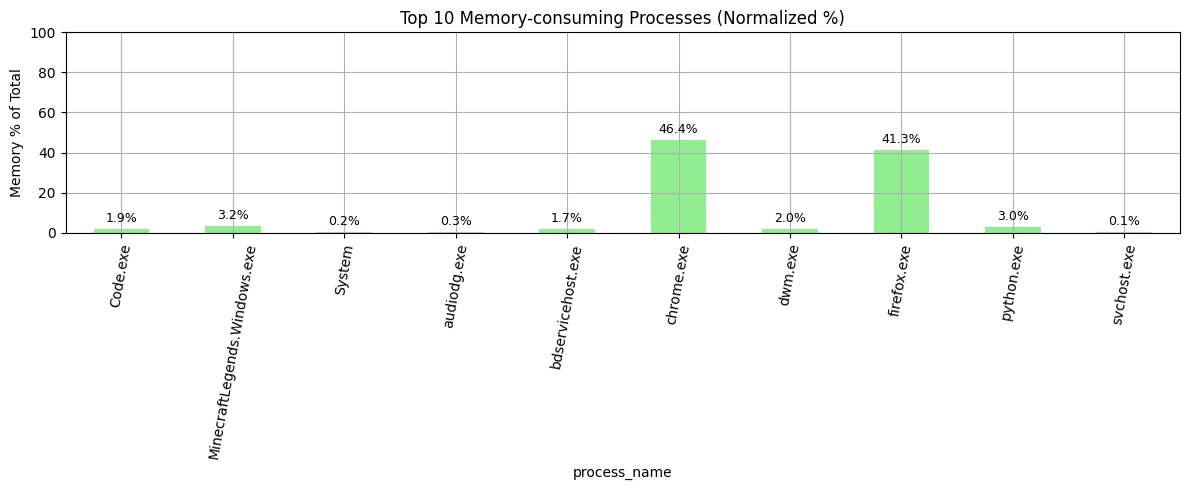

In [69]:
plt.figure(figsize=(12,5))
ax = memory_total_norm.plot(kind='bar', color='lightgreen')
plt.title('Top 10 Memory-consuming Processes (Normalized %)')
plt.ylabel('Memory % of Total')
plt.xticks(rotation=80)
plt.ylim(0,100)
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.1f}%', (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')
plt.tight_layout()
plt.grid(True)

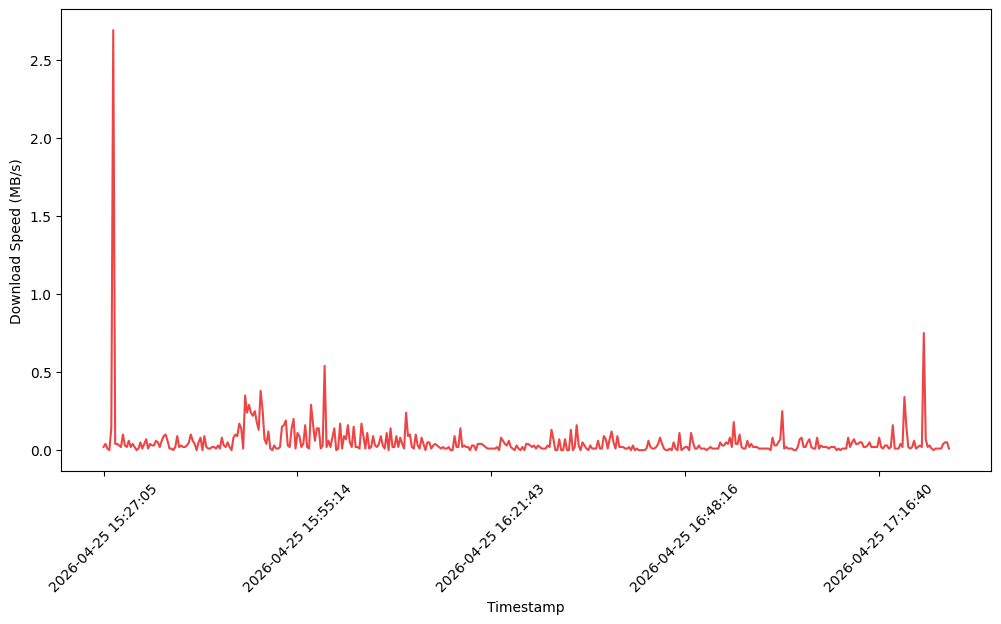

In [95]:
plt.subplots(figsize=(12,6))
plt.plot(df_network_metrics['timestamp'], df_network_metrics['upload_speed_mb'], color=RED)
plt.xlabel('Timestamp')
plt.ylabel('Download Speed (MB/s)')
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(5))
plt.xticks(rotation=45);

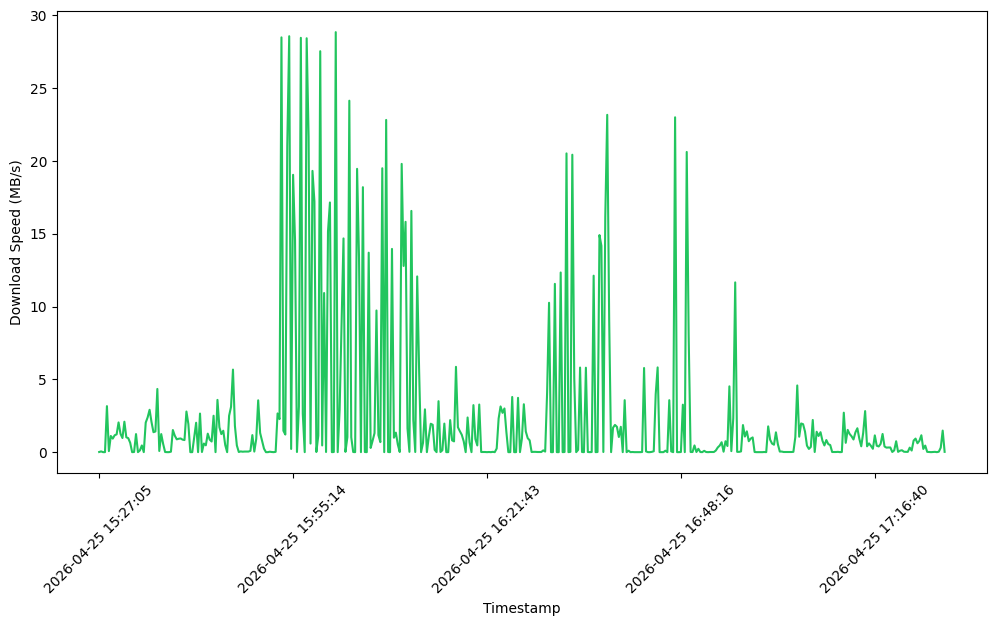

In [96]:
plt.subplots(figsize=(12,6))
plt.plot(df_network_metrics['timestamp'], df_network_metrics['download_speed_mb'], color=GREEN)
plt.xlabel('Timestamp')
plt.ylabel('Download Speed (MB/s)')
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(5))
plt.xticks(rotation=45);

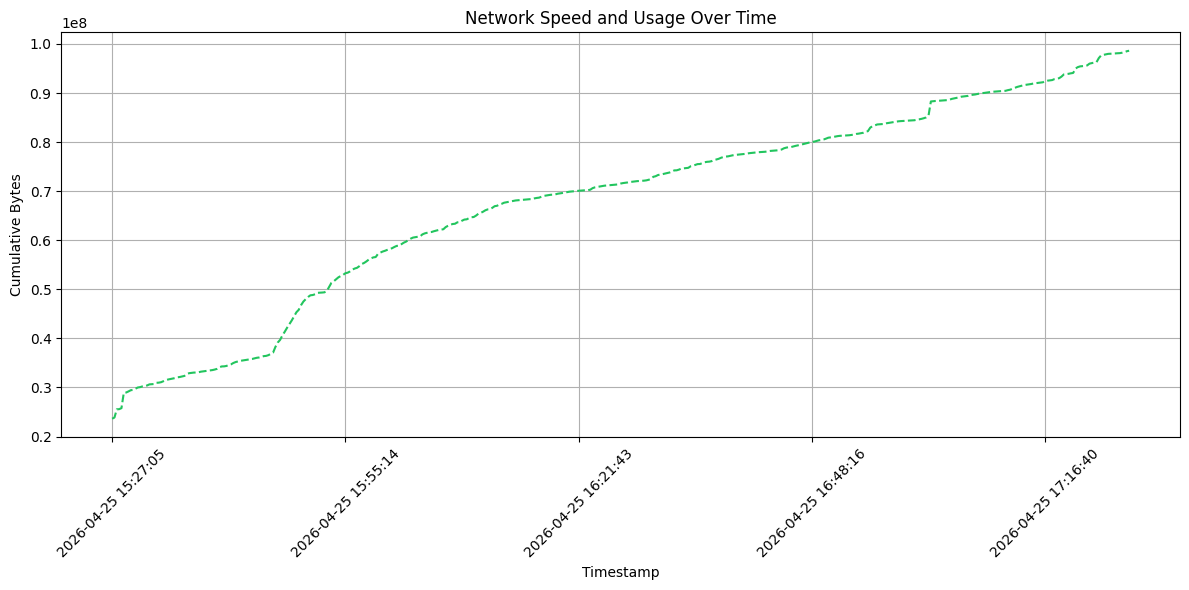

In [ ]:
plt.subplots(figsize=(12,6))
plt.plot(df_network_metrics['timestamp'], df_network_metrics['bytes_sent'],  color=GREEN, linestyle='--')
plt.xlabel("Timestamp")
plt.ylabel('Cumulative Bytes')
plt.title('Network Speed and Usage Over Time')
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(5))
plt.grid()
plt.tight_layout()

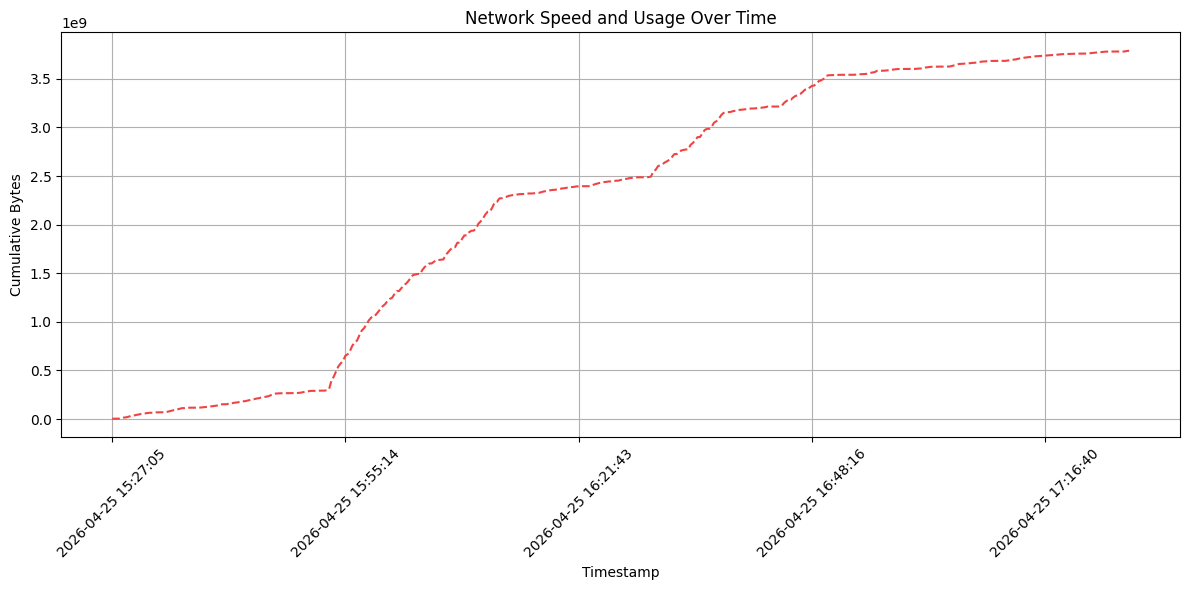

In [98]:
plt.subplots(figsize=(12,6))
plt.plot(df_network_metrics['timestamp'], df_network_metrics['bytes_received'],  color=RED, linestyle='--')
plt.xlabel("Timestamp")
plt.ylabel('Cumulative Bytes')
plt.title('Network Speed and Usage Over Time')
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(5))
plt.grid()
plt.tight_layout()